In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.discrete.discrete_model import MNLogit
from statsmodels.discrete.discrete_model import Logit

In [2]:
dataset = pd.read_csv(r'C:\Users\Spandan Dutta\econometrics_project\data\processed\master_panel.csv',parse_dates=['date'], index_col='date')
ns_df = pd.read_csv(r'C:\Users\Spandan Dutta\econometrics_project\outputs\tables\ns_factors_monthly.csv',parse_dates=['date'], index_col='date')
df = dataset.join(ns_df, how='inner')

In [5]:
#classification

def classify_regime(b1):
    if b1 < -0.5:
        return 'Normal'
    elif b1 > 0.5:
        return 'Inverted'
    else:
        return 'Flat'

df['regime'] = df['beta1'].apply(classify_regime)
print(df['regime'].value_counts())


regime
Normal      41
Flat        16
Inverted     1
Name: count, dtype: int64


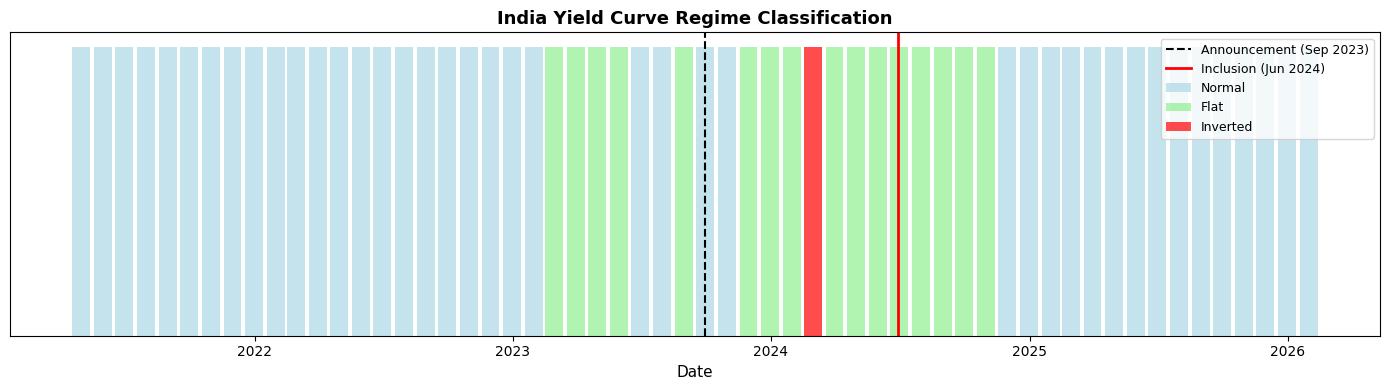

In [ ]:
#Regime timeline plot
regime_map = {'Normal': 0, 'Flat': 1, 'Inverted': 2}
df['regime_num'] = df['regime'].map(regime_map)

fig, ax = plt.subplots(figsize=(14, 4))

colors = {'Normal': 'lightblue', 'Flat': 'lightgreen', 'Inverted': 'red'}
for regime, color in colors.items():
    mask = df['regime'] == regime
    ax.bar(df.index[mask], [1]*mask.sum(),width=25, color=color, alpha=0.7, label=regime)

ax.axvline(pd.Timestamp('2023-09-30'), color='black', linestyle='--',linewidth=1.5, label='Announcement (Sep 2023)')
ax.axvline(pd.Timestamp('2024-06-28'), color='red', linestyle='-',linewidth=2, label='Inclusion (Jun 2024)')

ax.set_xlabel('Date', fontsize=11)
ax.set_title('India Yield Curve Regime Classification',fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_yticks([])
ax.grid(False)

plt.tight_layout()
plt.savefig(r'C:\Users\Spandan Dutta\econometrics_project\outputs\figures\regime_classification.png',dpi=150, bbox_inches='tight')
plt.show()


In [18]:
#binary logit 
df_binary=df[(df['regime'] == 'Normal') | (df['regime'] == 'Flat')].copy()
df_binary['flat'] = (df_binary['regime'] == 'Flat').astype(int)
features = ['jpmorgan_weight', 'd_us_10y', 'cpi']
diff_cols = ['us_10y', 'vix', 'dxy', 'brent', 'laf_net']
for col in diff_cols:
    df_binary[f'd_{col}'] = df_binary[col].diff()
reg_df = df_binary[['flat'] + features].dropna()
X = sm.add_constant(reg_df[features])
y = reg_df['flat']
logit = Logit(y, X).fit(maxiter=200, disp=False)
print(logit.summary())

                           Logit Regression Results                           
Dep. Variable:                   flat   No. Observations:                   46
Model:                          Logit   Df Residuals:                       42
Method:                           MLE   Df Model:                            3
Date:                Fri, 10 Apr 2026   Pseudo R-squ.:                  0.4987
Time:                        06:57:27   Log-Likelihood:                -14.900
converged:                       True   LL-Null:                       -29.720
Covariance Type:            nonrobust   LLR p-value:                 1.642e-06
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -65.1221     19.883     -3.275      0.001    -104.091     -26.153
jpmorgan_weight    -0.7914      0.283     -2.800      0.005      -1.345      -0.237
d_us_10y           -1.7458      